# Feature Selection — Hierarchical Funnel

**Purpose:** Select features using a structured, reproducible approach — not an arbitrary vote.

**Framework:**
1. **LightGBM gain ranking** — primary selector, aligned with final model architecture
2. **Boruta confirmation** — validates top features aren't fitting noise
3. **LASSO** — generates an alternative, parsimonious feature subset
4. **Competing subsets** — LGBM top-K, LASSO selected, intersection
5. **Cross-validation tie-breaker** — best subset wins on empirical AUCPR

**Data source:** `analytics_dataset` train split, after imputation.

## 0. Setup

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Notebook may be launched from anywhere — ensure mlops/ is on sys.path.
_NB_DIR = Path.cwd()
_PROJECT_ROOT = _NB_DIR
for _p in [_NB_DIR, *_NB_DIR.parents]:
    if (_p / "src" / "config.py").exists():
        _PROJECT_ROOT = _p
        break
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# All relative paths (artifacts, policy CSV) resolve from repo root.
os.chdir(str(_PROJECT_ROOT))

from src.bigquery import run_query
from src.config import (
    FULL_TABLE_REF, LABEL_COLUMN, NON_FEATURE_COLUMNS,
    SPLIT_COLUMN, SPLITS, PROJECT_ID,
)
from src.imputer import MissingnessImputer

warnings.filterwarnings("ignore", category=FutureWarning)

RID = datetime.now(timezone.utc).strftime("%Y%m%dt%H%M%S")
ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts" / "feature_selection" / RID
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID:     {RID}")
print(f"Artifacts:  {ARTIFACTS_DIR.relative_to(_PROJECT_ROOT)}")
print(f"Table:      {FULL_TABLE_REF}")

Run ID:     20260618t194046
Artifacts:  artifacts/feature_selection/20260618t194046
Table:      trim-icon-498815-a0.readmission.analytics_dataset


### 0.1 Load & Impute

Pull train and validation splits. Apply the missingness policy — fit imputer on train only, transform both. Label-encode categoricals so numeric methods work.

In [2]:
def load_data():
    """Load raw train/validation splits — NO imputation or encoding here.

    Imputation and encoding are deferred to individual pipeline stages
    (LGBM handles NaN + categoricals natively; LASSO/CV use Pipeline).
    """
    split_list = ", ".join(f"'{s}'" for s in SPLITS.values())
    sql = f"""
        SELECT *
        FROM `{FULL_TABLE_REF}`
        WHERE {SPLIT_COLUMN} IN ({split_list})
    """
    df = run_query(sql)

    train_df = df[df[SPLIT_COLUMN] == SPLITS["train"]].reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == SPLITS["validation"]].reset_index(drop=True)

    drop_cols = [c for c in NON_FEATURE_COLUMNS if c in train_df.columns and c != LABEL_COLUMN]
    drop_cols.append(SPLIT_COLUMN)
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    val_df = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])

    y_train = train_df.pop(LABEL_COLUMN).astype(int)
    y_val = val_df.pop(LABEL_COLUMN).astype(int)

    return train_df, val_df, y_train, y_val


X_train_raw, X_val_raw, y_train, y_val = load_data()

# Identify column types for downstream encoding decisions.
CAT_COLS = [c for c in X_train_raw.columns
            if X_train_raw[c].dtype in ("object", "category")
            or str(X_train_raw[c].dtype) == "category"]
NUM_COLS = [c for c in X_train_raw.columns if c not in CAT_COLS]

print(f"Train: {X_train_raw.shape}  Val: {X_val_raw.shape}")
print(f"Features: {len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical")
print(f"Label prevalence (train): {y_train.mean():.4f}")

Train: (247687, 50)  Val: (48924, 50)
Features: 43 numeric, 7 categorical
Label prevalence (train): 0.2094


## 1. Primary Selector — LightGBM Gain Ranking

Train LightGBM on all features. Extract gain importance — the total reduction in loss from splits on each feature. This is our primary ranking because the final model will also be a gradient-boosted tree.

In [3]:
# Prepare data for LightGBM: cast categoricals to 'category' dtype so LGBM
# handles them natively. NaN is handled by LGBM automatically.
X_tr_lgbm = X_train_raw.copy()
X_val_lgbm = X_val_raw.copy()
for c in CAT_COLS:
    X_tr_lgbm[c] = X_tr_lgbm[c].astype('category')
    X_val_lgbm[c] = X_val_lgbm[c].astype('category').cat.set_categories(
        X_tr_lgbm[c].cat.categories
    )

lgbm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, verbose=-1,
)
lgbm.fit(
    X_tr_lgbm, y_train,
    categorical_feature=CAT_COLS,
    eval_set=[(X_val_lgbm, y_val)],
)

val_aucpr = average_precision_score(y_val, lgbm.predict_proba(X_val_lgbm)[:, 1])
print(f"LGBM val AUCPR: {val_aucpr:.4f}  (HOSPITAL baseline: 0.3325)")

gain_df = pd.DataFrame({
    "feature": X_train_raw.columns,
    "gain": lgbm.feature_importances_,
    "gain_pct": lgbm.feature_importances_ / lgbm.feature_importances_.sum() * 100,
}).sort_values("gain", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = range(1, len(gain_df) + 1)
gain_df["cumulative_gain"] = gain_df["gain_pct"].cumsum()

print(f"\nFeatures with any gain: {(gain_df.gain > 0).sum()}/{len(gain_df)}")

print("\n=== Top 25 by gain ===")
for _, r in gain_df.head(25).iterrows():
    bar = "█" * max(1, int(r["gain_pct"] * 3))
    print(f"  {r['gain_rank']:3d}. {r['feature']:<38s} {r['gain_pct']:5.1f}%  {bar}")

out = ARTIFACTS_DIR / "lgbm_gain.csv"
gain_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")

LGBM val AUCPR: 0.4025  (HOSPITAL baseline: 0.3325)

Features with any gain: 44/50

=== Top 25 by gain ===
    1. race                                     7.2%  █████████████████████
    2. discharge_location                       5.9%  █████████████████
    3. age                                      5.0%  ███████████████
    4. recent_ed_visits                         4.1%  ████████████
    5. index_los_days                           3.7%  ███████████
    6. prior_inpatient_days                     3.6%  ██████████
    7. admission_type                           3.4%  ██████████
    8. glucose_max                              3.0%  █████████
    9. medication_order_count                   3.0%  █████████
   10. prior_admission_count                    2.8%  ████████
   11. glucose_delta                            2.7%  ████████
   12. glucose_last                             2.6%  ███████
   13. rbc_max                                  2.6%  ███████
   14. medication_count           

### 1.1 Cumulative gain — where to draw the line?

In [4]:
for t in [50, 70, 80, 90, 95]:
    n = (gain_df["cumulative_gain"] >= t).idxmax()
    print(f"  {t}% of gain captured by top {n + 1} features")

  50% of gain captured by top 14 features
  70% of gain captured by top 22 features
  80% of gain captured by top 27 features
  90% of gain captured by top 33 features
  95% of gain captured by top 37 features


## 2. Boruta Confirmation

Take the top LGBM features and ask: "Do these consistently outperform randomized shadows?" Boruta validates — it doesn't vote. Rejected features are flagged as potentially spurious.

In [5]:
BORUTA_TOP_N = 30
boruta_features = gain_df.head(BORUTA_TOP_N)["feature"].tolist()
print(f"Running Boruta on top {BORUTA_TOP_N} LGBM features...")

# Boruta uses RandomForest — needs numeric, non-null input.
# Impute + one-hot encode the top-N feature slice on train only.
boruta_cat = [c for c in boruta_features if c in CAT_COLS]
boruta_num = [c for c in boruta_features if c in NUM_COLS]

X_boruta_raw = X_train_raw[boruta_features].copy()
imputer_boruta = MissingnessImputer()
X_boruta_imp = imputer_boruta.fit_transform(X_boruta_raw)

if boruta_cat:
    ohe_boruta = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    X_boruta_cat_encoded = ohe_boruta.fit_transform(X_boruta_imp[boruta_cat].astype(str))
    X_boruta_num_arr = X_boruta_imp[boruta_num].fillna(0).values if boruta_num else np.empty((len(X_boruta_imp), 0))
    X_boruta_arr = np.hstack([X_boruta_num_arr, X_boruta_cat_encoded])
    boruta_feature_names = (boruta_num +
                            [f"{c}_{v}" for c, cats in zip(boruta_cat, ohe_boruta.categories_)
                             for v in cats[1:]])
else:
    X_boruta_arr = X_boruta_imp[boruta_num].fillna(0).values
    boruta_feature_names = boruta_num

rf = RandomForestClassifier(n_jobs=-1, max_depth=7, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", perc=100, random_state=42, verbose=0)
boruta.fit(X_boruta_arr, y_train.values)

# Map Boruta decisions back to original feature names.
# For one-hot expanded features, a categorical is "Confirmed" if ANY dummy survived.
boruta_support_map: dict[str, bool] = {}
for expanded_name, supported in zip(boruta_feature_names, boruta.support_):
    # Resolve expanded name (e.g., "race_Black") back to original ("race").
    resolved = expanded_name
    for bf in boruta_features:
        if expanded_name == bf or expanded_name.startswith(bf + '_'):
            resolved = bf
            break
    if resolved not in boruta_support_map:
        boruta_support_map[resolved] = supported
    else:
        boruta_support_map[resolved] = boruta_support_map[resolved] or supported

decisions = ["Confirmed" if boruta_support_map.get(f, False) else "Rejected"
             for f in boruta_features]
boruta_df = pd.DataFrame({
    "feature": boruta_features,
    "decision": decisions,
    "boruta_rank": boruta.ranking_[:len(boruta_features)],
    "lgbm_gain_pct": [gain_df[gain_df.feature == f].iloc[0]["gain_pct"] for f in boruta_features],
}).sort_values(["decision", "boruta_rank"])

Running Boruta on top 30 LGBM features...


### Boruta Evaluation

Compare Boruta's verdict against LGBM's gain ranking. A feature that LGBM ranks highly but Boruta rejects is a red flag — the model may be fitting noise. A feature both agree on is solid.

In [6]:
# Agreement — compare Boruta verdicts against LGBM ranking
boruta_set = set(boruta_df[boruta_df.decision == "Confirmed"]["feature"])
lgbm_set = set(gain_df.head(BORUTA_TOP_N)["feature"])
agreement = boruta_set & lgbm_set
print(f"\n=== Agreement (both methods, top {BORUTA_TOP_N}) ===")
print(f"  In both: {len(agreement)}")
print(f"  Boruta-confirmed but outside LGBM top-{BORUTA_TOP_N}: {len(boruta_set - lgbm_set)}")
print(f"  LGBM top-{BORUTA_TOP_N} but rejected by Boruta: {len(lgbm_set - boruta_set)}")


=== Agreement (both methods, top 30) ===
  In both: 30
  Boruta-confirmed but outside LGBM top-30: 0
  LGBM top-30 but rejected by Boruta: 0


## 3. LASSO — Alternative Subset Generator

LASSO produces a parsimonious, linear-perspective feature set. Used to construct Subset B (LASSO-selected) and Subset C (intersection with LGBM).

In [7]:
# --- Build preprocessor: OneHotEncoder for categoricals, StandardScaler for numerics ---
# LASSO requires numeric, non-null input. Fit imputer + encoder on a train subsample.
n_sample = min(50000, len(X_train_raw))
idx = np.random.RandomState(42).choice(len(X_train_raw), n_sample, replace=False)

X_lasso_raw = X_train_raw.iloc[idx].copy()
y_lasso = y_train.iloc[idx]

# Impute on the subsample.
imputer_lasso = MissingnessImputer()
X_lasso_imp = imputer_lasso.fit_transform(X_lasso_raw)

# Build ColumnTransformer: scale numerics, one-hot encode categoricals.
lasso_cat = [c for c in CAT_COLS if c in X_lasso_imp.columns]
lasso_num = [c for c in NUM_COLS if c in X_lasso_imp.columns]

transformers = []
if lasso_num:
    transformers.append(('num', StandardScaler(), lasso_num))
if lasso_cat:
    transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False,
                                              handle_unknown='ignore'), lasso_cat))

preprocessor = ColumnTransformer(transformers, remainder='drop')
Xt_s = preprocessor.fit_transform(X_lasso_imp)

# Map expanded feature names back to originals for subset construction.
ohe = preprocessor.named_transformers_.get('cat', None)
expanded_names = list(lasso_num)  # numerics pass through unchanged
if ohe is not None and lasso_cat:
    for cat_col, categories in zip(lasso_cat, ohe.categories_):
        for cat_val in categories[1:]:  # drop='first' skips the first category
            expanded_names.append(f"{cat_col}_{cat_val}")

# --- C-tuning via grid search on the subsample ---
# Target: find the smallest C whose AUCPR is within 4% relative of best,
# producing a parsimonious (~20-30) feature set.
# Uses elasticnet with l1_ratio=1.0 (equivalent to LASSO, avoids deprecation).
C_candidates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
c_results = []

for C_val in C_candidates:
    lasso = LogisticRegression(penalty="elasticnet", solver="saga", C=C_val,
                               l1_ratio=1.0, max_iter=1000, random_state=42)
    cv_scores = cross_validate(
        lasso, Xt_s, y_lasso,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='average_precision',
        return_estimator=True,
    )
    mean_aucpr = cv_scores['test_score'].mean()
    # Average number of non-zero coefs across folds
    n_nonzero = np.mean([(est.coef_[0] != 0).sum() for est in cv_scores['estimator']])
    c_results.append({'C': C_val, 'aucpr': mean_aucpr, 'n_features': int(n_nonzero)})
    print(f"  C={C_val:<6}  AUCPR={mean_aucpr:.4f}  n_features≈{int(n_nonzero)}")

c_df = pd.DataFrame(c_results)
best_aucpr = c_df['aucpr'].max()
# Use 96% threshold (4% relative drop) — stricter than before to favor parsimony.
# This selects the smallest C whose AUCPR is ≥ 96% of the best observed.
target_aucpr = best_aucpr * 0.96
qualifying = c_df[c_df['aucpr'] >= target_aucpr]
parsimonious = qualifying.sort_values('n_features').iloc[0]
best_C = parsimonious['C']
print(f"\nBest AUCPR: {best_aucpr:.4f}  |  96% threshold: {target_aucpr:.4f}")
print(f"Chosen C={best_C} (AUCPR={parsimonious['aucpr']:.4f}, "
      f"n_features≈{parsimonious['n_features']})")

# Refit final LASSO with the chosen C on the full subsample.
lasso = LogisticRegression(penalty="elasticnet", solver="saga", C=best_C,
                           l1_ratio=1.0, max_iter=1000, random_state=42)
lasso.fit(Xt_s, y_lasso)

# --- Map coefficients back to original feature names ---
# For one-hot features, aggregate abs(coef) across dummy levels to decide selection.
coef_map: dict[str, float] = {}
coef_abs_map: dict[str, float] = {}
for name, coef in zip(expanded_names, lasso.coef_[0]):
    # Resolve to original feature name.
    orig = name
    for c in lasso_cat:
        if name.startswith(c + '_') or name == c:
            orig = c
            break
    coef_map[orig] = coef_map.get(orig, 0.0) + coef
    coef_abs_map[orig] = coef_abs_map.get(orig, 0.0) + abs(coef)

# Ensure all original features appear (even those with zero coef).
lasso_df = pd.DataFrame({
    "feature": list(X_train_raw.columns),
})
lasso_df["coefficient"] = lasso_df["feature"].map(coef_map).fillna(0.0)
lasso_df["abs_coef"] = lasso_df["feature"].map(coef_abs_map).fillna(0.0)
lasso_df["selected"] = lasso_df["abs_coef"] > 0
lasso_df = lasso_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

n_sel = lasso_df["selected"].sum()
print(f"\nLASSO selected {n_sel}/{len(lasso_df)} features (C={best_C})\n")

print("=== Top 15 LASSO features ===")
for _, r in lasso_df[lasso_df.selected].head(15).iterrows():
    print(f"  {r.feature:<38s} {r.coefficient:+.4f}")

out = ARTIFACTS_DIR / "lasso_coefficients.csv"
lasso_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")
print(f"C-tuning log: {ARTIFACTS_DIR / 'lasso_c_tuning.csv'}")
c_df.to_csv(ARTIFACTS_DIR / "lasso_c_tuning.csv", index=False)

  C=0.001   AUCPR=0.3545  n_features≈7
  C=0.005   AUCPR=0.3656  n_features≈20
  C=0.01    AUCPR=0.3730  n_features≈32
  C=0.02    AUCPR=0.3809  n_features≈43
  C=0.05    AUCPR=0.3851  n_features≈50
  C=0.1     AUCPR=0.3864  n_features≈57

Best AUCPR: 0.3864  |  96% threshold: 0.3709
Chosen C=0.01 (AUCPR=0.3730, n_features≈32.0)

LASSO selected 37/50 features (C=0.01)

=== Top 15 LASSO features ===
  admission_type                         +0.1801
  discharge_location                     +0.0728
  race                                   -0.2678
  prior_admission_count                  +0.2136
  oncology_flag                          +0.1713
  sodium_measured                        +0.1244
  gender                                 +0.1239
  rdw_min                                +0.1021
  recent_ed_visits                       +0.1020
  age                                    -0.0830
  rbc_last                               -0.0665
  sodium_min                             -0.0651
  hemoglob

## 4. Construct Competing Subsets

- **A (LGBM top-K):** Top 25 by gain, Boruta-confirmed — trust the tree
- **B (LASSO selected):** Non-zero coefficients after C-tuning — linear, parsimonious
- **C (Intersection):** Only features in both A and B — strict consensus
- **D (Intersection-Plus):** Intersection + any LGBM top-10 not already in C — balanced

In [8]:
LGBM_TOP_K = 25
lgbm_confirmed = set(boruta_df[boruta_df.decision == "Confirmed"]["feature"])
subset_a = [f for f in gain_df.head(LGBM_TOP_K)["feature"] if f in lgbm_confirmed]
subset_b = lasso_df[lasso_df.selected]["feature"].tolist()
subset_c = [f for f in subset_a if f in subset_b]

# Intersection-Plus: intersection of A and B, plus any LGBM top-10 not already
# included. Balances both perspectives at ~20-30 features.
lgbm_top10 = set(gain_df.head(10)["feature"])
subset_d = list(dict.fromkeys(subset_c + [f for f in gain_df["feature"]
                                          if f in lgbm_top10 and f not in subset_c]))

print(f"Subset A (LGBM top-{LGBM_TOP_K}, Boruta-confirmed): {len(subset_a)} features")
print(f"Subset B (LASSO selected, C-tuned):                 {len(subset_b)} features")
print(f"Subset C (Intersection A ∩ B):                      {len(subset_c)} features")
print(f"Subset D (Intersection-Plus):                       {len(subset_d)} features")

subsets = {
    "A_LGBM": subset_a,
    "B_LASSO": subset_b,
    "C_Intersection": subset_c,
    "D_IntersectionPlus": subset_d,
}

Subset A (LGBM top-25, Boruta-confirmed): 25 features
Subset B (LASSO selected, C-tuned):                 37 features
Subset C (Intersection A ∩ B):                      20 features
Subset D (Intersection-Plus):                       20 features


## 5. Cross-Validation Tie-Breaker

5-fold CV with XGBoost per subset. The subset with the highest mean validation AUCPR wins.

In [9]:
# --- 5-fold CV with Pipeline: imputation + encoding fitted INSIDE each fold ---
# This eliminates the data leakage from pre-imputing on the full training set.
# Each fold's imputer/encoder sees only that fold's training portion.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, features in subsets.items():
    # Identify which features in this subset are categorical vs numeric.
    sub_cat = [c for c in features if c in CAT_COLS]
    sub_num = [c for c in features if c in NUM_COLS]

    # Build ColumnTransformer for this subset.
    sub_transformers = []
    if sub_num:
        sub_transformers.append(('num', StandardScaler(), sub_num))
    if sub_cat:
        sub_transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False,
                                                      handle_unknown='ignore'), sub_cat))
    preproc = ColumnTransformer(sub_transformers, remainder='drop')

    pipeline = Pipeline([
        ('imputer', MissingnessImputer()),
        ('preprocessor', preproc),
        ('model', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                random_state=42, verbosity=0)),
    ])

    X_sub = X_train_raw[features]
    cv_results = cross_validate(
        pipeline, X_sub, y_train,
        cv=cv,
        scoring='average_precision',
        return_train_score=False,
    )

    fold_scores = cv_results['test_score']
    results[name] = {
        "features": features,
        "n_features": len(features),
        "mean_aucpr": np.mean(fold_scores),
        "std_aucpr": np.std(fold_scores),
        "fold_scores": list(fold_scores),
        "pipeline": pipeline,  # refit on full train later for DCA
    }
    print(f"  {name:<22s}  {len(features):2d} features  "
          f"AUCPR = {results[name]['mean_aucpr']:.4f} "
          f"(±{results[name]['std_aucpr']:.4f})")

# --- Parsimony-aware tie-breaker ---
# More features must earn their keep with a meaningful AUCPR improvement.
# Rule: if subset X has more features than Y but AUCPR gain < 1% relative,
# prefer the smaller subset.
PARSIMONY_THRESHOLD = 0.01  # 1% relative AUCPR improvement required per extra feature

sorted_by_aucpr = sorted(results.items(), key=lambda kv: kv[1]['mean_aucpr'], reverse=True)
best_name, best_res = sorted_by_aucpr[0]
winner = best_name

for name, res in sorted_by_aucpr[1:]:
    current_best = results[winner]
    aucpr_gain = (best_res['mean_aucpr'] / max(res['mean_aucpr'], 1e-9)) - 1.0
    if (res['n_features'] < current_best['n_features']
            and aucpr_gain < PARSIMONY_THRESHOLD):
        winner = name
        print(f"\n  Parsimony rule: {winner} preferred over {best_name} "
              f"({current_best['n_features']}→{res['n_features']} features, "
              f"AUCPR gain only {aucpr_gain * 100:.2f}% < {PARSIMONY_THRESHOLD * 100:.0f}%)")
        best_name, best_res = name, res

if winner == sorted_by_aucpr[0][0]:
    print(f"\n✓ Winner: {winner}  (AUCPR = {results[winner]['mean_aucpr']:.4f})  "
          f"[best AUCPR, no parsimony override needed]")
else:
    print(f"\n✓ Winner: {winner}  (AUCPR = {results[winner]['mean_aucpr']:.4f})  "
          f"[parsimony override applied]")

  A_LGBM                  25 features  AUCPR = 0.4037 (±0.0080)
  B_LASSO                 37 features  AUCPR = 0.4114 (±0.0075)
  C_Intersection          20 features  AUCPR = 0.4007 (±0.0075)
  D_IntersectionPlus      20 features  AUCPR = 0.4007 (±0.0075)

✓ Winner: B_LASSO  (AUCPR = 0.4114)  [best AUCPR, no parsimony override needed]


### 5.1 CV score distribution

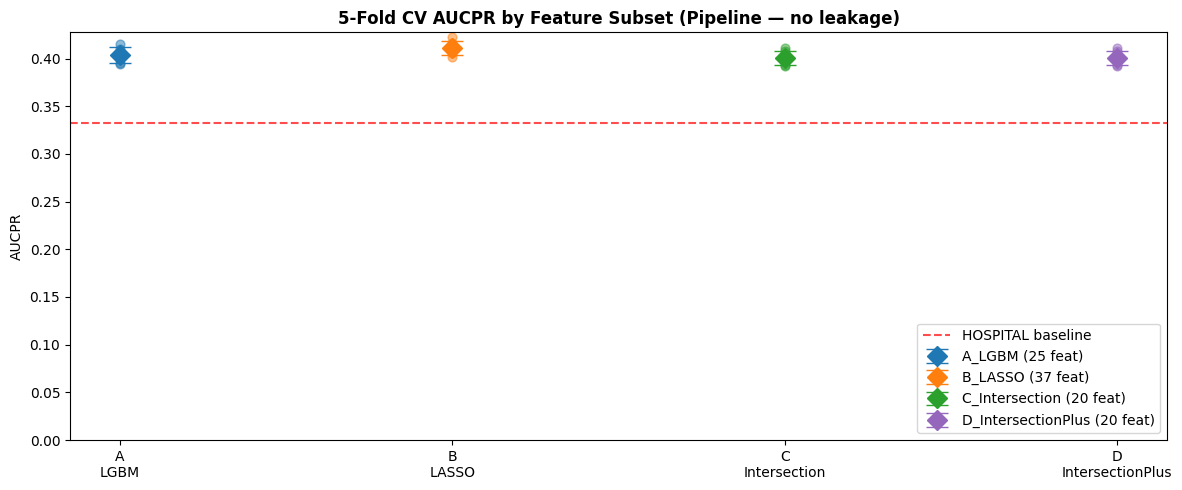

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
positions = range(len(results))

colors = {
    "A_LGBM": "#1f77b4",
    "B_LASSO": "#ff7f0e",
    "C_Intersection": "#2ca02c",
    "D_IntersectionPlus": "#9467bd",
}
for i, (name, res) in enumerate(results.items()):
    ax.scatter([i] * len(res["fold_scores"]), res["fold_scores"],
               alpha=0.5, s=40, color=colors.get(name, "#888888"))
    ax.errorbar(i, res["mean_aucpr"], yerr=res["std_aucpr"],
                fmt="D", capsize=8, markersize=10, linewidth=2,
                color=colors.get(name, "#888888"),
                label=f"{name} ({res['n_features']} feat)")

ax.axhline(y=0.3325, color="red", linestyle="--", alpha=0.7, label="HOSPITAL baseline")
ax.set_xticks(positions)
ax.set_xticklabels([k.replace('_', '\n') for k in results.keys()])
ax.set_ylabel("AUCPR")
ax.set_title("5-Fold CV AUCPR by Feature Subset (Pipeline — no leakage)", fontweight="bold")
ax.legend(loc="lower right")
ax.set_ylim(0.0, None)
plt.tight_layout()
plt.show()

## D. Decision Curve Analysis

DCA answers: if a clinician used this model to decide who to intervene on, would patients be better off?

- **Treat All** — intervene on every patient (catches all readmissions, maximum false positives)
- **Treat None** — intervene on no one (no false positives, misses all readmissions)
- **Model** — intervene only when predicted risk ≥ threshold

A model has clinical value where its curve is *above* both defaults.

Model adds clinical value for risk thresholds 2%–50%


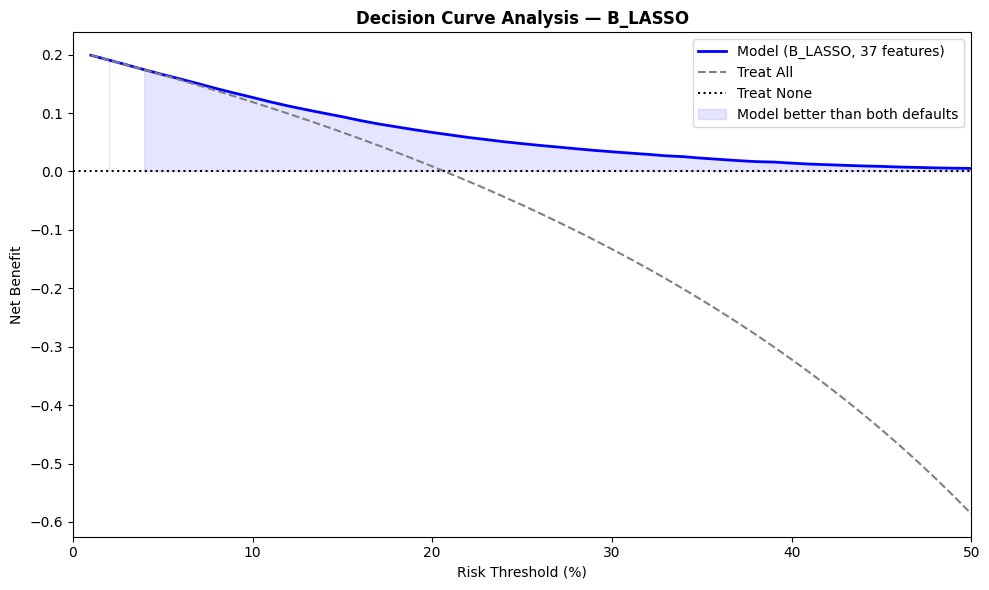

In [11]:
# Train winning pipeline on full train, predict on validation set.
winner_features = results[winner]["features"]
winner_pipeline = results[winner]["pipeline"]

X_tr_win = X_train_raw[winner_features]
X_val_win = X_val_raw[winner_features]

winner_pipeline.fit(X_tr_win, y_train)
probs = winner_pipeline.predict_proba(X_val_win)[:, 1]

# DCA: net benefit at each threshold
thresholds = np.linspace(0.01, 0.50, 50)
n = len(y_val)

net_benefit_model = []
net_benefit_all = []

for t in thresholds:
    pred_pos = probs >= t
    tp = (pred_pos & (y_val == 1)).sum()
    fp = (pred_pos & (y_val == 0)).sum()
    # Net benefit = TP/N - FP/N × (t / (1-t))
    nb = tp / n - (fp / n) * (t / (1 - t))
    net_benefit_model.append(nb)
    # Treat all: TP = all positives, FP = all negatives
    nb_all = (y_val == 1).sum() / n - ((y_val == 0).sum() / n) * (t / (1 - t))
    net_benefit_all.append(nb_all)

# Treat none: net benefit = 0 at all thresholds

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds * 100, net_benefit_model, "b-", linewidth=2,
        label=f"Model ({winner}, {len(winner_features)} features)")
ax.plot(thresholds * 100, net_benefit_all, "gray", linestyle="--",
        label="Treat All")
ax.axhline(y=0, color="black", linestyle=":", label="Treat None")

# Shade the region where the model adds value
ax.fill_between(thresholds * 100, net_benefit_model, 0,
                 where=(np.array(net_benefit_model) > 0) & (np.array(net_benefit_model) > np.array(net_benefit_all)),
                 alpha=0.1, color="blue", label="Model better than both defaults")

ax.set_xlabel("Risk Threshold (%)")
ax.set_ylabel("Net Benefit")
ax.set_title(f"Decision Curve Analysis — {winner}", fontweight="bold")
ax.legend(loc="upper right")
ax.set_xlim(0, 50)

# Annotate the threshold range where model is useful
model_better = np.where((np.array(net_benefit_model) > 0) & (np.array(net_benefit_model) > np.array(net_benefit_all)))[0]
if len(model_better) > 0:
    t_start = thresholds[model_better[0]] * 100
    t_end = thresholds[model_better[-1]] * 100
    print(f"Model adds clinical value for risk thresholds {t_start:.0f}%–{t_end:.0f}%")
else:
    print("Model does not outperform both defaults at any threshold")

plt.tight_layout()
plt.show()

## 6. Export Final Shortlist

In [12]:
winner_features = results[winner]["features"]

shortlist_df = pd.DataFrame({
    "feature": winner_features,
    "decision": "KEEP",
    "source": winner,
})
for i, row in shortlist_df.iterrows():
    g = gain_df[gain_df.feature == row["feature"]]
    if len(g):
        shortlist_df.at[i, "lgbm_gain_pct"] = round(g.iloc[0]["gain_pct"], 2)
        shortlist_df.at[i, "lgbm_rank"] = int(g.iloc[0]["gain_rank"])

out = ARTIFACTS_DIR / "feature_shortlist.csv"
shortlist_df.to_csv(out, index=False)
print(f"Saved: {out.name}")
print(f"\nFinal shortlist: {len(shortlist_df)} features ({winner})")
print(f"CV AUCPR: {results[winner]['mean_aucpr']:.4f} (±{results[winner]['std_aucpr']:.4f})")

print("\n=== Final Features ===")
for _, r in shortlist_df.iterrows():
    print(f"  {r['feature']:<38s}  gain={r['lgbm_gain_pct']:5.1f}%  rank={r['lgbm_rank']:.0f}")

Saved: feature_shortlist.csv

Final shortlist: 37 features (B_LASSO)
CV AUCPR: 0.4114 (±0.0075)

=== Final Features ===
  admission_type                          gain=  3.4%  rank=7
  discharge_location                      gain=  5.9%  rank=2
  race                                    gain=  7.2%  rank=1
  prior_admission_count                   gain=  2.8%  rank=10
  oncology_flag                           gain=  1.8%  rank=27
  sodium_measured                         gain=  0.0%  rank=49
  gender                                  gain=  0.8%  rank=40
  rdw_min                                 gain=  2.0%  rank=23
  recent_ed_visits                        gain=  4.1%  rank=4
  age                                     gain=  5.0%  rank=3
  rbc_last                                gain=  2.2%  rank=20
  sodium_min                              gain=  1.5%  rank=34
  hemoglobin_last                         gain=  1.4%  rank=35
  prior_inpatient_days                    gain=  3.6%  rank=6
  so

## 7. Summary

| Step | Method | Role |
|---|---|---|
| 1 | LightGBM gain | Primary selector — ranks all features (native categorical handling) |
| 2 | Boruta | Confirmation gate — rejects features indistinguishable from noise |
| 3 | LASSO + C-tuning | Subset generator — one-hot encoded categoricals, parsimony-optimized C |
| 4 | Four subsets | LGBM top-K, LASSO selected, intersection, intersection-plus |
| 5 | 5-fold CV (Pipeline) | Tie-breaker — imputation + encoding inside each fold (no leakage) |
| 6 | Parsimony rule | Extra features must earn ≥1% AUCPR improvement |
| 7 | Export | `feature_shortlist.csv` with winning features |

**Key fixes vs. original:**
- Categoricals are one-hot encoded for linear models (not label-encoded)
- Imputation/encoding happens inside CV folds via `sklearn.pipeline.Pipeline`
- LASSO C is tuned to balance performance and parsimony
- Parsimony-aware tie-breaker prevents over-selection

**HOSPITAL baseline AUCPR:** 0.3325